In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

sns.set(style="whitegrid")
df = pd.read_csv("../data/insider_threat_logs.csv", parse_dates=["date"])
features_df = pd.read_csv("../data/features.csv")
df.head()

,user_id,date,logon_count,after_hours_logons,usb_connections,files_copied_to_usb,files_accessed,emails_sent,emails_to_external,http_requests,unique_devices_used,session_duration_hrs,is_malicious
0,USER0000,2024-01-01,3,0,1,1,11,8,0,44,1,6.61,0
1,USER0000,2024-01-02,1,2,0,0,17,7,1,40,1,7.92,0
2,USER0000,2024-01-03,0,0,0,0,19,8,2,44,1,4.68,0
3,USER0000,2024-01-04,3,1,0,2,18,4,1,39,1,9.90,0
4,USER0000,2024-01-05,2,0,0,4,15,7,1,33,1,7.37,0


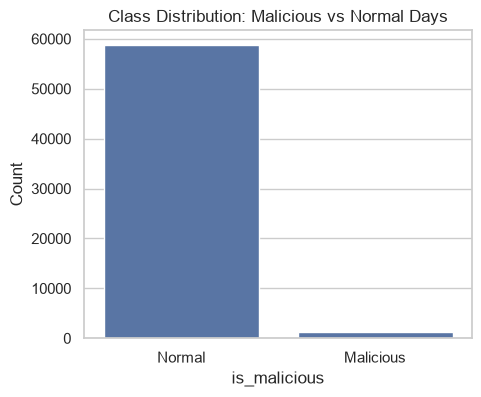

is_malicious
0    97.971667
1     2.028333
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(5,4))
sns.countplot(x="is_malicious", data=df)
plt.title("Class Distribution: Malicious vs Normal Days")
plt.xticks([0,1], ["Normal", "Malicious"])
plt.ylabel("Count")
plt.show()

print(df["is_malicious"].value_counts(normalize=True) * 100)

C:\Users\Dell\AppData\Local\Temp\ipykernel_17512\2910981254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Normal", "Malicious"])
C:\Users\Dell\AppData\Local\Temp\ipykernel_17512\2910981254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Normal", "Malicious"])
C:\Users\Dell\AppData\Local\Temp\ipykernel_17512\2910981254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Normal", "Malicious"])
C:\Users\Dell\AppData\Local\Temp\ipykernel_17512\2910981254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

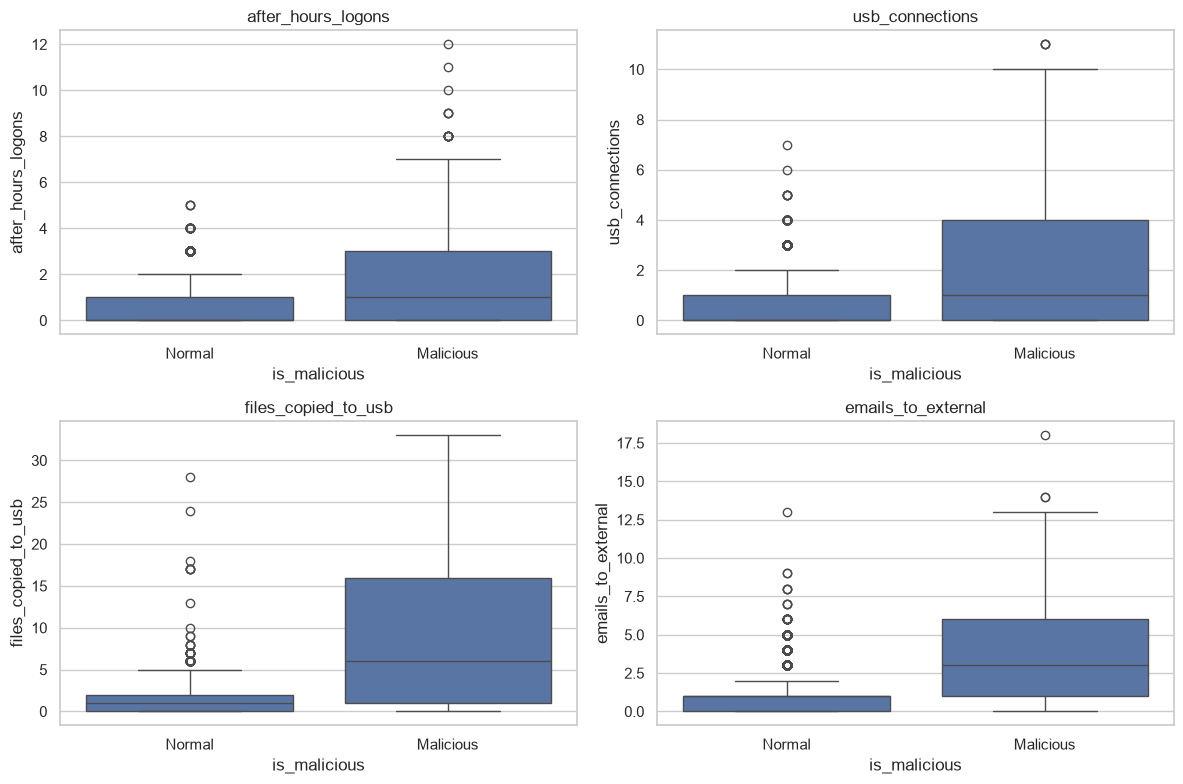

In [3]:
key_features = ["after_hours_logons", "usb_connections", "files_copied_to_usb", "emails_to_external"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, key_features):
    sns.boxplot(x="is_malicious", y=col, data=df, ax=ax)
    ax.set_xticklabels(["Normal", "Malicious"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

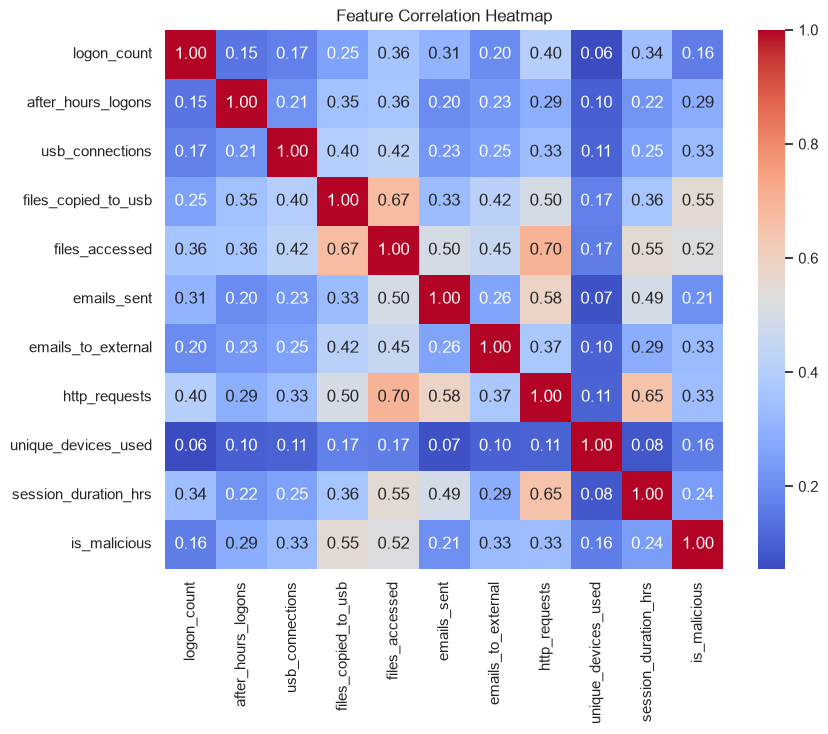

In [4]:
numeric_cols = ["logon_count","after_hours_logons","usb_connections",
                 "files_copied_to_usb","files_accessed","emails_sent",
                 "emails_to_external","http_requests","unique_devices_used",
                 "session_duration_hrs","is_malicious"]

plt.figure(figsize=(9,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
results_df = pd.read_csv("../outputs/model_comparison.csv")
results_df_sorted = results_df.sort_values("f1_score", ascending=False)
results_df_sorted

,model,precision,recall,f1_score,roc_auc
0,CatBoost,0.9835,0.4897,0.6538,0.7383
1,LightGBM,0.9833,0.4856,0.6501,0.7380
2,XGBoost,0.9833,0.4856,0.6501,0.7310
3,RandomForest,0.9154,0.4897,0.6381,0.7488
4,AdaBoost,0.5284,0.4979,0.5127,0.7284


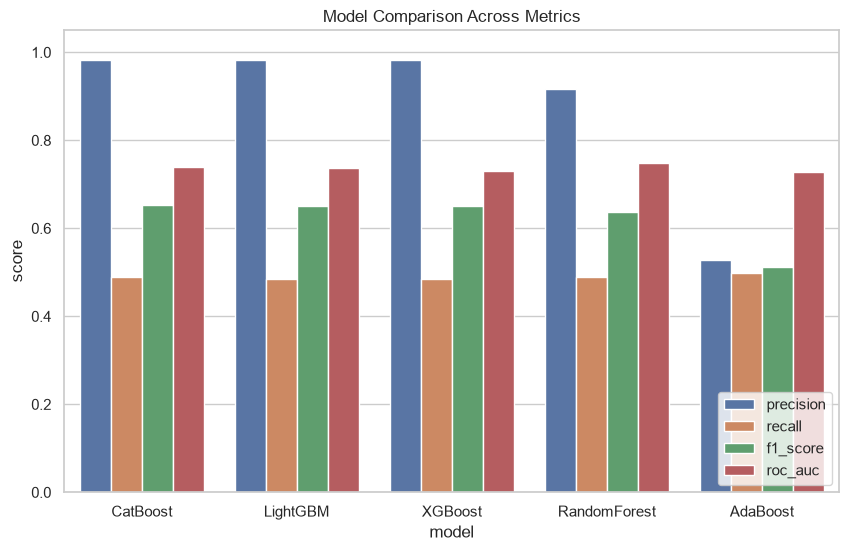

In [6]:
metrics = ["precision", "recall", "f1_score", "roc_auc"]
results_melted = results_df_sorted.melt(id_vars="model", value_vars=metrics,
                                          var_name="metric", value_name="score")

plt.figure(figsize=(10,6))
sns.barplot(x="model", y="score", hue="metric", data=results_melted)
plt.title("Model Comparison Across Metrics")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()

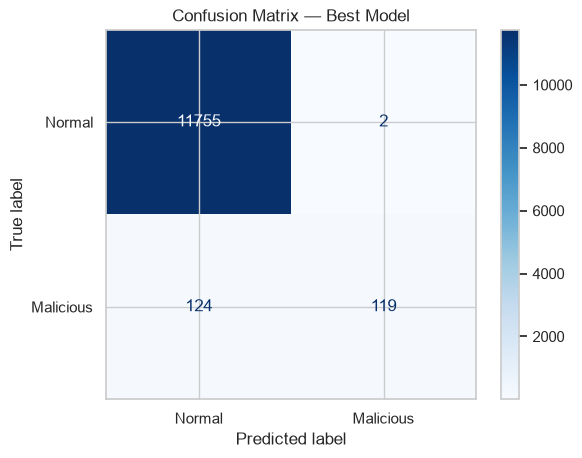

In [7]:
model = joblib.load("../models/best_model.pkl")
scaler = joblib.load("../models/scaler.pkl")
feature_cols = joblib.load("../models/feature_columns.pkl")

X = features_df[feature_cols]
y = features_df["is_malicious"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

preds = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Malicious"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Best Model")
plt.show()

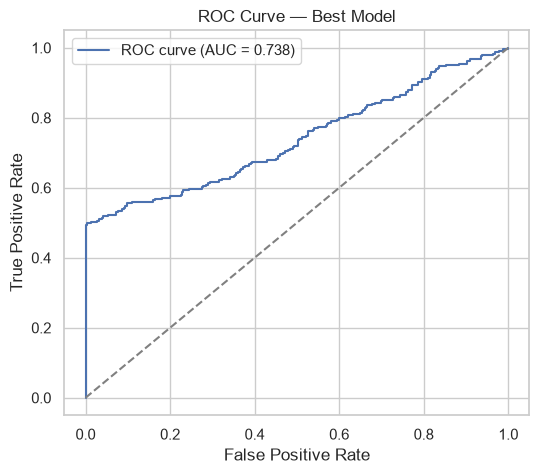

In [8]:
probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Best Model")
plt.legend()
plt.show()

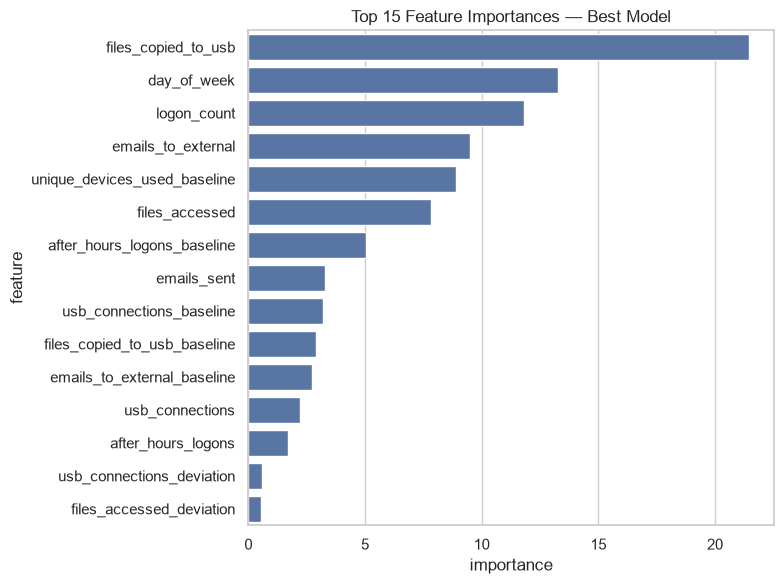

In [9]:
importances = model.feature_importances_
imp_df = pd.DataFrame({"feature": feature_cols, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=imp_df)
plt.title("Top 15 Feature Importances — Best Model")
plt.tight_layout()
plt.show()